<a href="https://colab.research.google.com/github/valesed/GitHub-Repository-for-CPE311/blob/main/Hands_on_Activity_9_2_Customized_Visualizations_using_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

earthquakes = pd.read_csv("/content/earthquakes.csv")
faang = pd.read_csv("/content/fb_stock_prices_2018 (1).csv")
faang['date'] = pd.to_datetime(faang['date'])
faang.set_index('date', inplace=True)

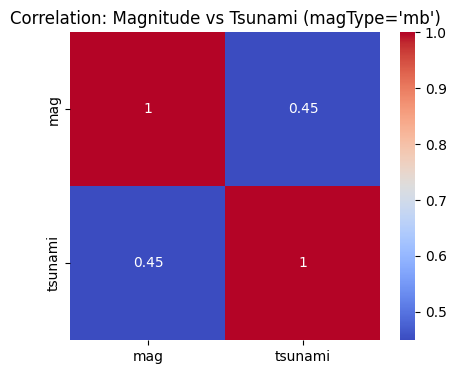

In [ ]:
mb_quakes = earthquakes[earthquakes['magType'] == 'mb'][['mag','tsunami']]
correlation = mb_quakes.corr()
plt.figure(figsize=(5,4))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation: Magnitude vs Tsunami (magType='mb')")
plt.show()

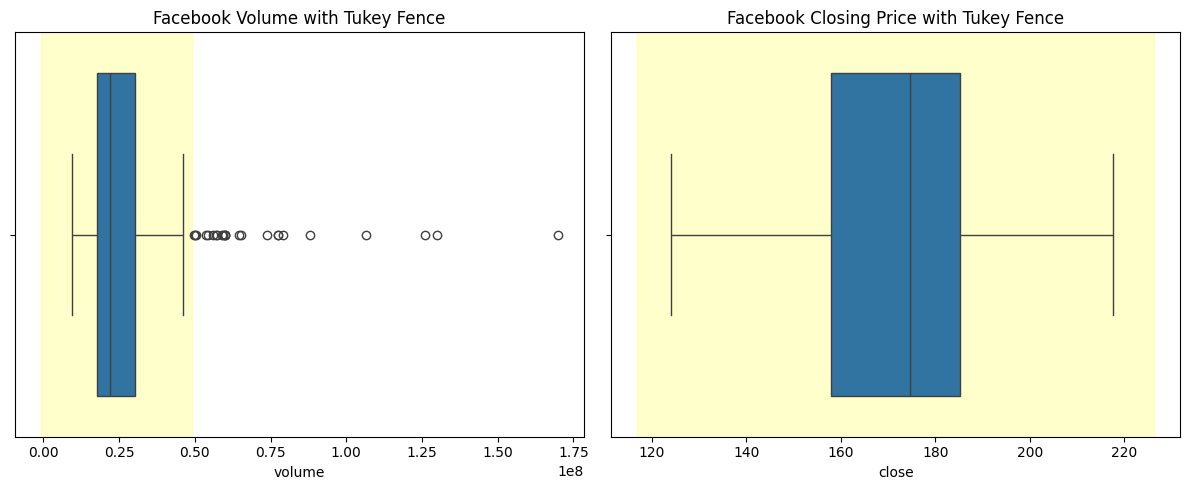

In [ ]:
fb = faang
Q1 = fb[['volume','close']].quantile(0.25)
Q3 = fb[['volume','close']].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(x='volume', data=fb, ax=axes[0])
axes[0].axvspan(lower_bound['volume'], upper_bound['volume'], color='yellow', alpha=0.2)
axes[0].set_title("Facebook Volume with Tukey Fence")
sns.boxplot(x='close', data=fb, ax=axes[1])
axes[1].axvspan(lower_bound['close'], upper_bound['close'], color='yellow', alpha=0.2)
axes[1].set_title("Facebook Closing Price with Tukey Fence")
plt.tight_layout()
plt.show()

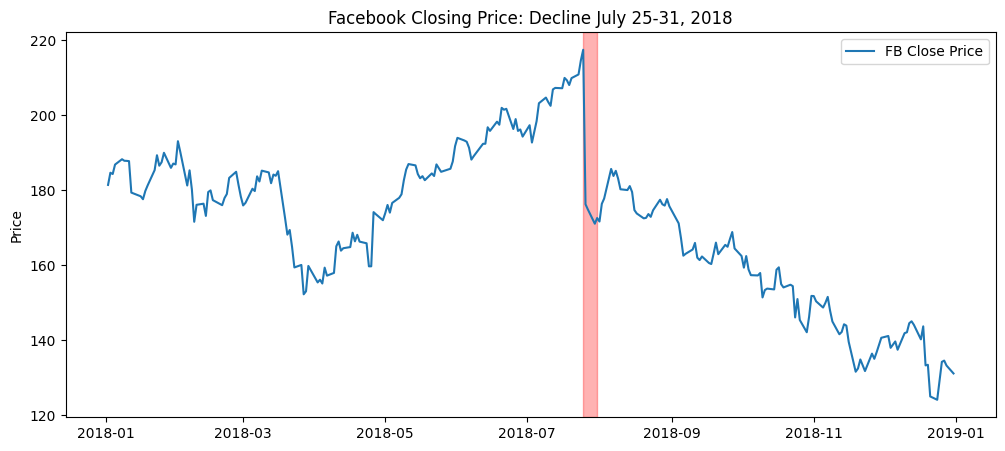

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(fb.index, fb['close'], label='FB Close Price')
plt.axvspan(pd.to_datetime('2018-07-25'), pd.to_datetime('2018-07-31'), color='red', alpha=0.3)
plt.title("Facebook Closing Price: Decline July 25-31, 2018")
plt.ylabel("Price")
plt.legend()
plt.show()

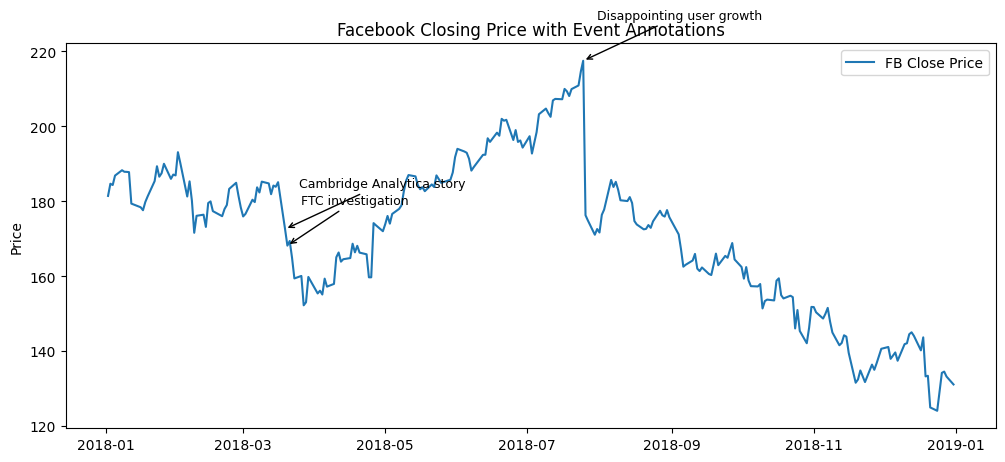

In [ ]:
events = {
    '2018-07-25': "Disappointing user growth",
    '2018-03-19': "Cambridge Analytica story",
    '2018-03-20': "FTC investigation"
}
plt.figure(figsize=(12,5))
plt.plot(fb.index, fb['close'], label='FB Close Price')
for date, label in events.items():
    plt.annotate(label,
                 xy=(pd.to_datetime(date), fb.loc[pd.to_datetime(date),'close']),
                 xytext=(10,30),
                 textcoords='offset points',
                 arrowprops=dict(facecolor='black', arrowstyle='->'),
                 fontsize=9)
plt.title("Facebook Closing Price with Event Annotations")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
def reg_resid_plots(x, y, cmap='Set2'):
    plt.figure(figsize=(6,5))
    colors = sns.color_palette(cmap, n_colors=len(x))
    for i in range(len(x)):
        plt.scatter(x[i], y[i], color=colors[i])
    plt.title("Regression Residual Plot with Colormap")
    plt.xlabel("X")
    plt.ylabel("Residual")
    plt.show()

# **Summary/Conclusion:**
I analyzed earthquake and stock data using Python. I grouped and filtered data, calculated trends and growth, and visualized patterns with charts. This helped me understand important events and trends clearly